# 👖 Autoencoders on Fashion MNIST

In this notebook, we'll walk through the steps required to train your own autoencoder on the fashion MNIST dataset.

In [1]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [2]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, datasets, callbacks
import tensorflow.keras.backend as K

# from notebooks.utils import display

## 0. Parameters <a name="parameters"></a>

In [3]:
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 100
BUFFER_SIZE = 1000
VALIDATION_SPLIT = 0.2
EMBEDDING_DIM = 2
EPOCHS = 3

## 1. Prepare the data <a name="prepare"></a>

In [4]:
# Load the data
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = imgs.astype("float32") / 255.0
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=0.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

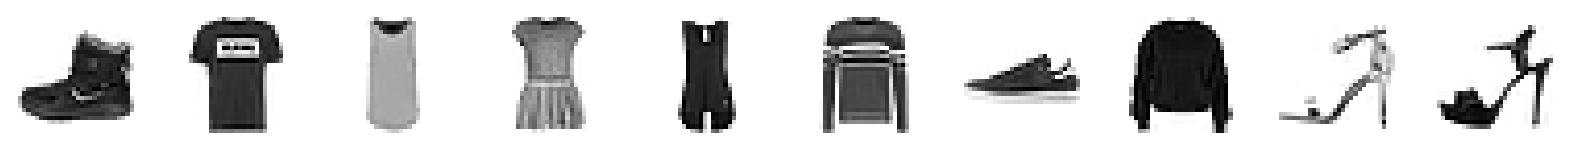

In [6]:
# Show some items of clothing from the training set
display(x_train)

## 2. Build the autoencoder <a name="build"></a>

In [9]:
# Encoder
encoder_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_input"
)
x = layers.Conv2D(32, (3, 3), strides=2, activation="relu", padding="same")(
    encoder_input
)
x = layers.Conv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), strides=2, activation="relu", padding="same")(x)
shape_before_flattening = K.int_shape(x)[1:]  # the decoder will need this!

x = layers.Flatten()(x)
encoder_output = layers.Dense(EMBEDDING_DIM, name="encoder_output")(x)

encoder = models.Model(encoder_input, encoder_output)
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,770 (378.01 KB)

 Trainable params: 96,770 (378.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Decoder
decoder_input = layers.Input(shape=(EMBEDDING_DIM,), name="decoder_input")
# orig
# x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
# alt 1
# x = layers.Dense(int(np.prod(shape_before_flattening)))(decoder_input)
# alt 2
decoder_units = int(np.prod(shape_before_flattening))
x = layers.Dense(decoder_units)(decoder_input)

x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(
    128, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    64, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    32, (3, 3), strides=2, activation="relu", padding="same"
)(x)
decoder_output = layers.Conv2D(
    CHANNELS,
    (3, 3),
    strides=1,
    activation="sigmoid",
    padding="same",
    name="decoder_output",
)(x)

decoder = models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,273 (962.00 KB)

 Trainable params: 246,273 (962.00 KB)

 Non-trainable params: 0 (0.00 B)

## Type check

In [13]:
type(shape_before_flattening)

tuple

In [14]:
np.prod(shape_before_flattening)

np.int64(2048)

In [12]:
type(decoder_units)

int

In [15]:
print(shape_before_flattening, type(shape_before_flattening))
print(np.prod(shape_before_flattening), type(np.prod(shape_before_flattening)))

(4, 4, 128) <class 'tuple'>
2048 <class 'numpy.int64'>


## Autoencoder

In [16]:
# Autoencoder
autoencoder = models.Model(
    encoder_input, decoder(encoder_output)
)  # decoder(encoder_output)
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 2)              │         4,098 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 32, 32, 1)      │       246,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,043 (1.31 MB)

 Trainable params: 343,043 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the autoencoder <a name="train"></a>

In [17]:
# Compile the autoencoder
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

In [22]:
# ran into an error 
# # Create a model save checkpoint
# model_checkpoint_callback = callbacks.ModelCheckpoint(
#     filepath="./checkpoint",
#     save_weights_only=False,
#     save_freq="epoch",
#     monitor="loss",
#     mode="min",
#     save_best_only=True,
#     verbose=0,
# )
# tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

In [19]:
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

In [20]:
autoencoder.fit(
    x_train,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[model_checkpoint_callback, tensorboard_callback],
)

Epoch 1/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 235s 386ms/step - loss: 0.2932 - val_loss: 0.2613
Epoch 2/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 248s 364ms/step - loss: 0.2572 - val_loss: 0.2560
Epoch 3/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 223s 372ms/step - loss: 0.2538 - val_loss: 0.2550


In [ ]:
# Keras 3 error
# # Save the final models
# autoencoder.save("./models/autoencoder")
# encoder.save("./models/encoder")
# decoder.save("./models/decoder")

In [23]:
import os
os.makedirs("./models", exist_ok=True)

autoencoder.save("./models/autoencoder.keras")
encoder.save("./models/encoder.keras")
decoder.save("./models/decoder.keras")

## 4. Reconstruct using the autoencoder <a name="reconstruct"></a>

In [24]:
n_to_predict = 5000
example_images = x_test[:n_to_predict]
example_labels = y_test[:n_to_predict]

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step
Example real clothing items


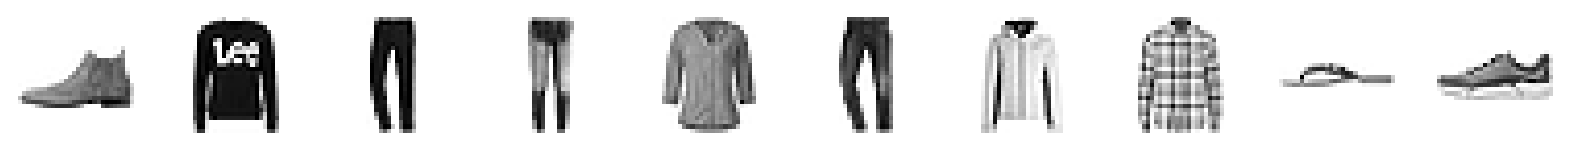

Reconstructions


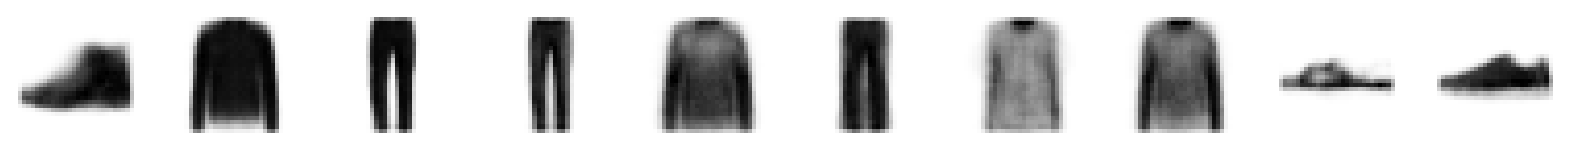

In [25]:
predictions = autoencoder.predict(example_images)

print("Example real clothing items")
display(example_images)
print("Reconstructions")
display(predictions)

### Evaluation

In [35]:
import numpy as np
import tensorflow as tf

# Use the same test subset you already predicted on
x_true = example_images
x_pred = predictions

# Ensure shape is [N, H, W, C]
if x_true.ndim == 3:
    x_true = np.expand_dims(x_true, -1)
if x_pred.ndim == 3:
    x_pred = np.expand_dims(x_pred, -1)

# Pixel-space errors
mse_per_img = np.mean((x_true - x_pred) ** 2, axis=(1, 2, 3))
mae_per_img = np.mean(np.abs(x_true - x_pred), axis=(1, 2, 3))

# PSNR (higher is better)
psnr_per_img = tf.image.psnr(x_true, x_pred, max_val=1.0).numpy()

# SSIM (higher is better, max 1.0)
ssim_per_img = tf.image.ssim(x_true, x_pred, max_val=1.0).numpy()

print("Reconstruction metrics on test subset")
print(f"MSE  mean={mse_per_img.mean():.6f}  std={mse_per_img.std():.6f}")
print(f"MAE  mean={mae_per_img.mean():.6f}  std={mae_per_img.std():.6f}")
print(f"PSNR mean={psnr_per_img.mean():.3f} dB  std={psnr_per_img.std():.3f}")
print(f"SSIM mean={ssim_per_img.mean():.4f}  std={ssim_per_img.std():.4f}")

# Show best and worst reconstructions by MSE
best_idx = np.argsort(mse_per_img)[:10]
worst_idx = np.argsort(mse_per_img)[-10:]

print("Best reconstruction indices:", best_idx)
print("Worst reconstruction indices:", worst_idx)

Reconstruction metrics on test subset
MSE  mean=0.023686  std=0.014313
MAE  mean=0.077644  std=0.031053
PSNR mean=16.930 dB  std=2.407
SSIM mean=0.5111  std=0.1773
Best reconstruction indices: [4469 1731 3429 1395  293 1169 2299 2391 2581 1216]
Worst reconstruction indices: [4390  622 2086 1286 3067  628 3070 4505 3999 4132]


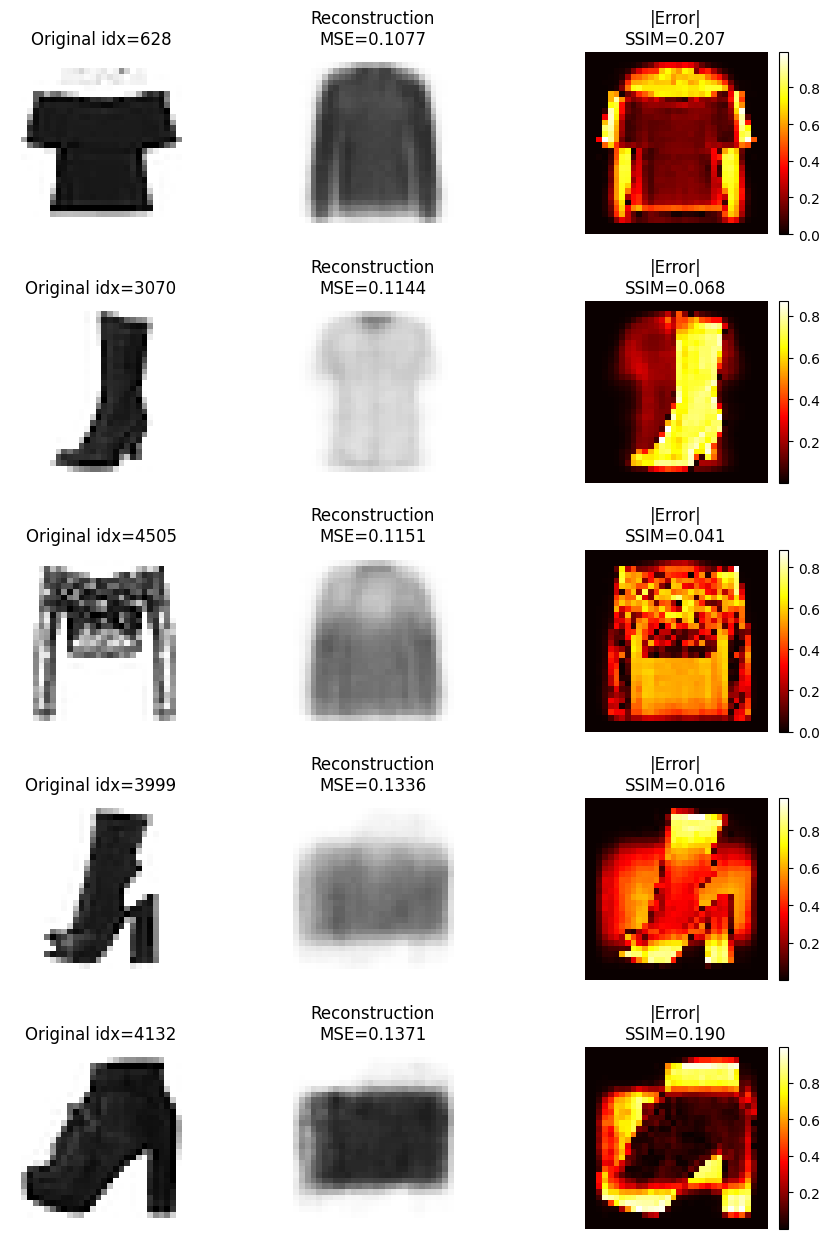

In [36]:
import matplotlib.pyplot as plt
import numpy as np

n_show = 5
idxs = worst_idx[-n_show:]  # uses indices from your MSE ranking

fig, axes = plt.subplots(n_show, 3, figsize=(9, 2.5 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(idxs):
    orig = x_true[idx]
    recon = x_pred[idx]

    # convert [H,W,1] -> [H,W] for display
    if orig.ndim == 3 and orig.shape[-1] == 1:
        orig_show = orig[..., 0]
    else:
        orig_show = np.squeeze(orig)

    if recon.ndim == 3 and recon.shape[-1] == 1:
        recon_show = recon[..., 0]
    else:
        recon_show = np.squeeze(recon)

    err = np.abs(orig_show - recon_show)

    axes[row, 0].imshow(orig_show, cmap="gray_r", vmin=0, vmax=1)
    axes[row, 0].set_title(f"Original idx={idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(recon_show, cmap="gray_r", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Reconstruction\nMSE={mse_per_img[idx]:.4f}")
    axes[row, 1].axis("off")

    im = axes[row, 2].imshow(err, cmap="hot")
    axes[row, 2].set_title(f"|Error|\nSSIM={ssim_per_img[idx]:.3f}")
    axes[row, 2].axis("off")
    fig.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 5. Embed using the encoder <a name="encode"></a>

In [26]:
# Encode the example images
embeddings = encoder.predict(example_images)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [27]:
# Some examples of the embeddings
print(embeddings[:10])

[[ 1.3656619   0.6005737 ]
 [ 0.13102204 -8.220983  ]
 [-9.296413   -2.5301416 ]
 [-5.934234   -1.2339897 ]
 [ 0.4172706  -4.225818  ]
 [-6.288992   -3.0678954 ]
 [-0.6932279  -2.4398282 ]
 [-0.1270272  -3.5844593 ]
 [-1.8731158   1.3448707 ]
 [-0.72262114  1.8807927 ]]


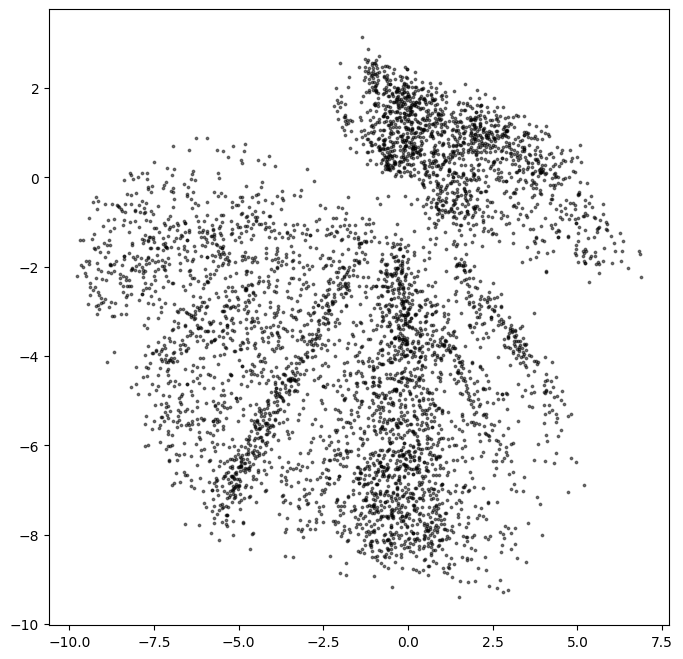

In [28]:
# Show the encoded points in 2D space
figsize = 8

plt.figure(figsize=(figsize, figsize))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c="black", alpha=0.5, s=3)
plt.show()

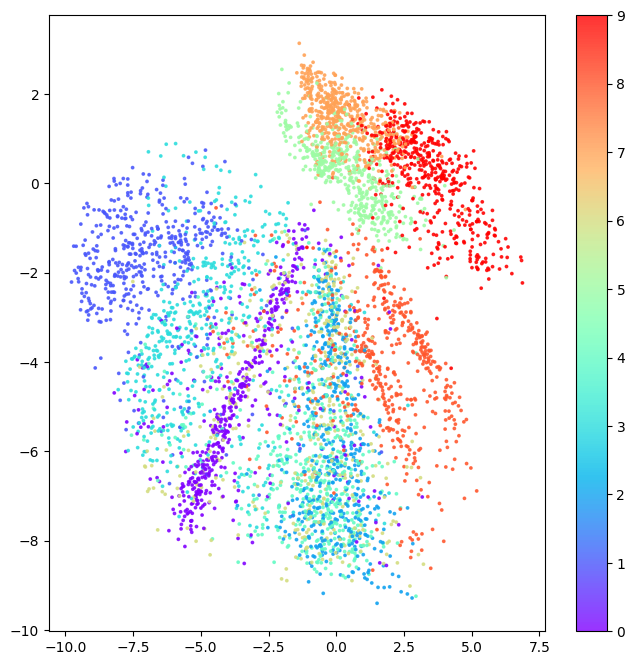

In [29]:
# Colour the embeddings by their label (clothing type - see table)
example_labels = y_test[:n_to_predict]

figsize = 8
plt.figure(figsize=(figsize, figsize))
plt.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    cmap="rainbow",
    c=example_labels,
    alpha=0.8,
    s=3,
)
plt.colorbar()
plt.show()

## 6. Generate using the decoder <a name="decode"></a>

In [30]:
# Get the range of the existing embeddings
mins, maxs = np.min(embeddings, axis=0), np.max(embeddings, axis=0)

# Sample some points in the latent space
grid_width, grid_height = (6, 3)
sample = np.random.uniform(
    mins, maxs, size=(grid_width * grid_height, EMBEDDING_DIM)
)

In [31]:
# Decode the sampled points
reconstructions = decoder.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


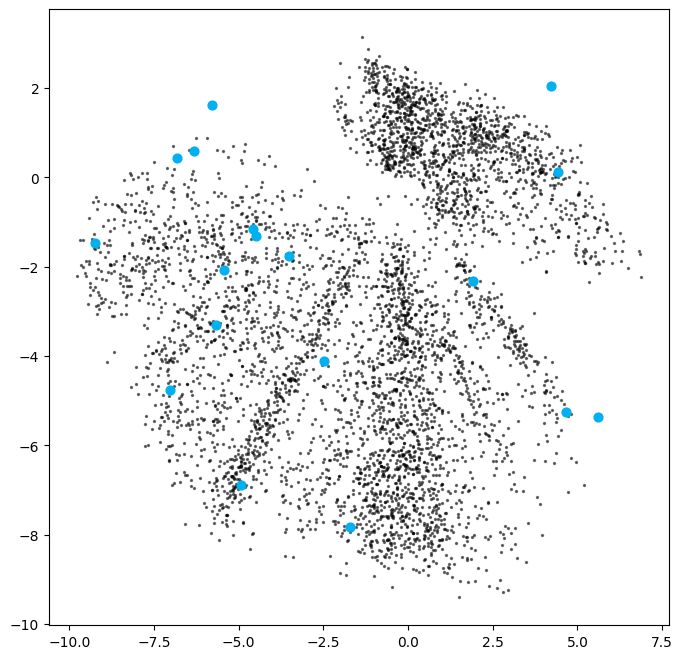

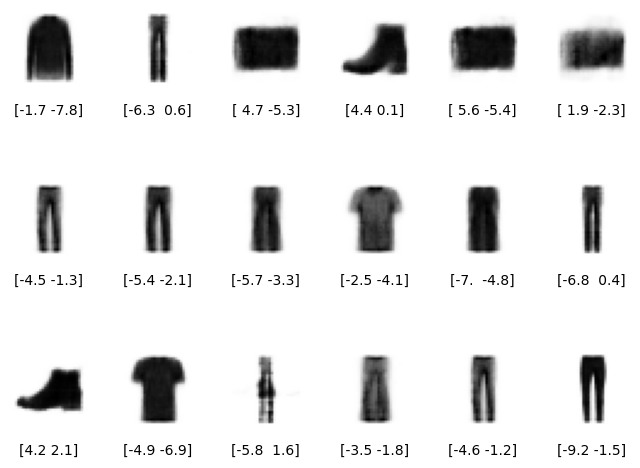

In [32]:
# Draw a plot of...
figsize = 8
plt.figure(figsize=(figsize, figsize))

# ... the original embeddings ...
plt.scatter(embeddings[:, 0], embeddings[:, 1], c="black", alpha=0.5, s=2)

# ... and the newly generated points in the latent space
plt.scatter(sample[:, 0], sample[:, 1], c="#00B0F0", alpha=1, s=40)
plt.show()

# Add underneath a grid of the decoded images
fig = plt.figure(figsize=(figsize, grid_height * 2))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        str(np.round(sample[i, :], 1)),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(reconstructions[i, :, :], cmap="Greys")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


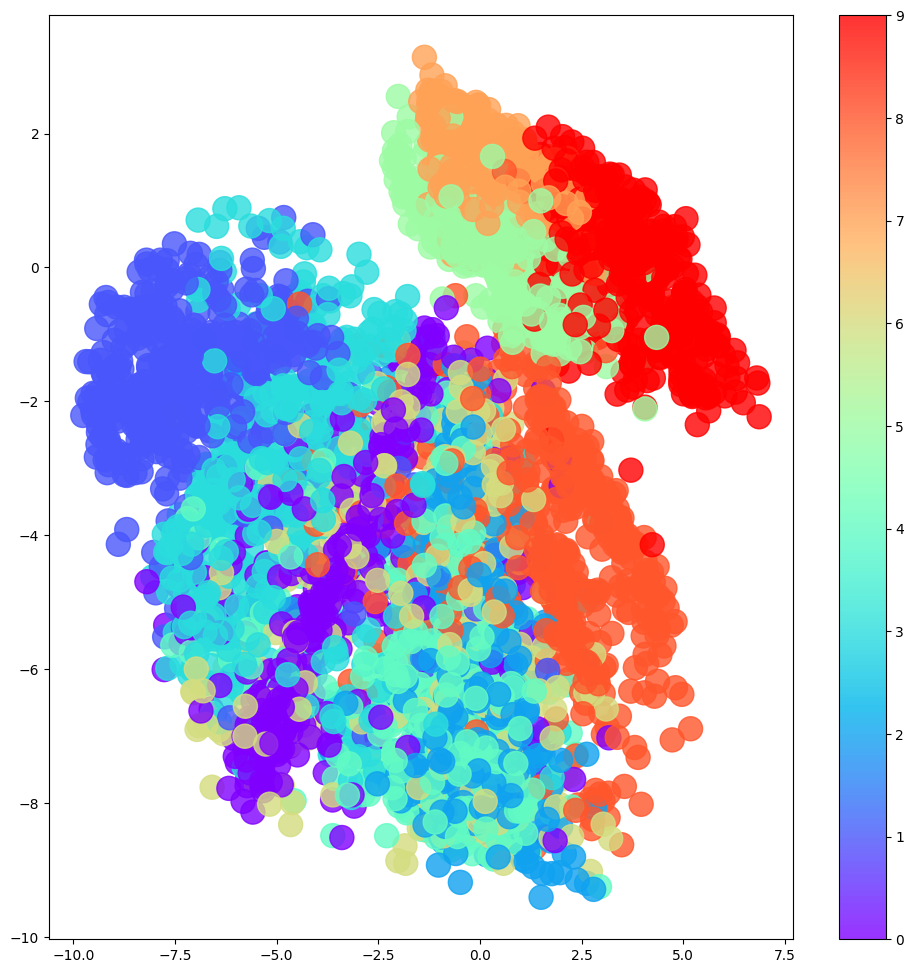

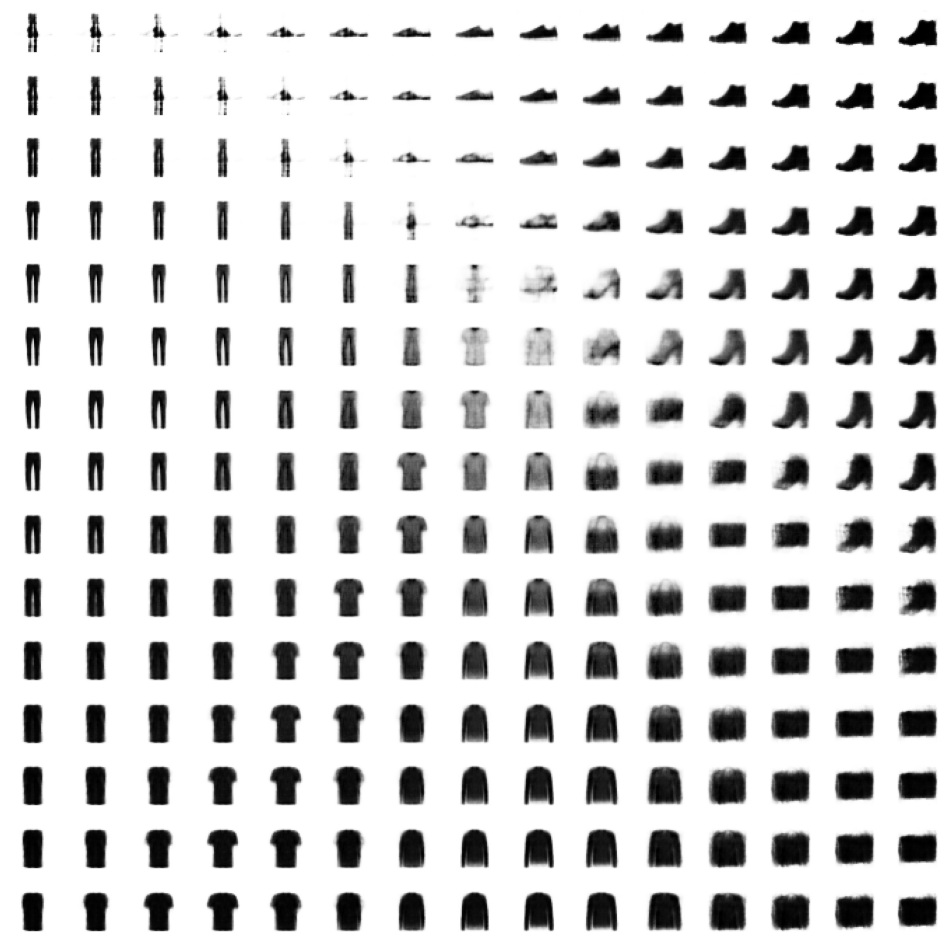

In [33]:
# Colour the embeddings by their label (clothing type - see table)
figsize = 12
grid_size = 15
plt.figure(figsize=(figsize, figsize))
plt.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    cmap="rainbow",
    c=example_labels,
    alpha=0.8,
    s=300,
)
plt.colorbar()

x = np.linspace(min(embeddings[:, 0]), max(embeddings[:, 0]), grid_size)
y = np.linspace(max(embeddings[:, 1]), min(embeddings[:, 1]), grid_size)
xv, yv = np.meshgrid(x, y)
xv = xv.flatten()
yv = yv.flatten()
grid = np.array(list(zip(xv, yv)))

reconstructions = decoder.predict(grid)
# plt.scatter(grid[:, 0], grid[:, 1], c="black", alpha=1, s=10)
plt.show()

fig = plt.figure(figsize=(figsize, figsize))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(grid_size**2):
    ax = fig.add_subplot(grid_size, grid_size, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :], cmap="Greys")